# Walmart Sales EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

In [2]:
df = pd.read_csv('walmart_sales_cleaned.csv')

In [3]:
df.head()
df.tail()
df.shape
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   transaction_id          5000 non-null   int64  
 1   customer_id             5000 non-null   int64  
 2   product_id              5000 non-null   int64  
 3   product_name            5000 non-null   object 
 4   category                5000 non-null   object 
 5   quantity_sold           5000 non-null   int64  
 6   unit_price              5000 non-null   float64
 7   transaction_date        5000 non-null   object 
 8   store_id                5000 non-null   int64  
 9   store_location          5000 non-null   object 
 10  inventory_level         5000 non-null   int64  
 11  reorder_point           5000 non-null   int64  
 12  reorder_quantity        5000 non-null   int64  
 13  supplier_id             5000 non-null   int64  
 14  supplier_lead_time      5000 non-null   

Index(['transaction_id', 'customer_id', 'product_id', 'product_name',
       'category', 'quantity_sold', 'unit_price', 'transaction_date',
       'store_id', 'store_location', 'inventory_level', 'reorder_point',
       'reorder_quantity', 'supplier_id', 'supplier_lead_time', 'customer_age',
       'customer_gender', 'customer_income', 'customer_loyalty_level',
       'payment_method', 'promotion_applied', 'promotion_type',
       'weather_conditions', 'holiday_indicator', 'weekday',
       'stockout_indicator', 'forecasted_demand', 'actual_demand', 'revenue',
       'forecast_error'],
      dtype='object')

In [4]:
# missing values
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

Series([], dtype: int64)

In [5]:
# duplicate records
df.duplicated().sum()
df[df.duplicated()]

,transaction_id,customer_id,product_id,product_name,category,quantity_sold,unit_price,transaction_date,store_id,store_location,inventory_level,reorder_point,reorder_quantity,supplier_id,supplier_lead_time,customer_age,customer_gender,customer_income,customer_loyalty_level,payment_method,promotion_applied,promotion_type,weather_conditions,holiday_indicator,weekday,stockout_indicator,forecasted_demand,actual_demand,revenue,forecast_error


In [6]:
# unique values
df.nunique().sort_values(ascending=False)

transaction_id            5000
customer_income           4998
revenue                   4975
transaction_date          4970
unit_price                4946
customer_id               3848
product_id                 898
inventory_level            501
actual_demand              421
supplier_id                401
forecasted_demand          401
forecast_error             395
reorder_quantity           201
reorder_point              101
customer_age                53
store_id                    20
supplier_lead_time          10
product_name                 8
weekday                      7
promotion_type               5
quantity_sold                5
store_location               5
customer_loyalty_level       4
weather_conditions           4
payment_method               4
customer_gender              3
category                     2
promotion_applied            2
stockout_indicator           2
holiday_indicator            2
dtype: int64

In [7]:
# check categorical columns
categorical_cols = df.select_dtypes(include="object").columns
categorical_cols

Index(['product_name', 'category', 'transaction_date', 'store_location',
       'customer_gender', 'customer_loyalty_level', 'payment_method',
       'promotion_type', 'weather_conditions', 'weekday'],
      dtype='object')

In [8]:
# check numerical columns
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
numerical_cols

Index(['transaction_id', 'customer_id', 'product_id', 'quantity_sold',
       'unit_price', 'store_id', 'inventory_level', 'reorder_point',
       'reorder_quantity', 'supplier_id', 'supplier_lead_time', 'customer_age',
       'customer_income', 'forecasted_demand', 'actual_demand', 'revenue',
       'forecast_error'],
      dtype='object')

In [9]:
# create revenue column if not already created
df["revenue"] = df["quantity_sold"] * df["unit_price"]

# create understock flag
df["understock_flag"] = df["inventory_level"] < df["actual_demand"]

# create forecast error percentage if not already created
df["absolute_forecast_error"] = abs(df["actual_demand"] - df["forecasted_demand"])

df["forecast_error_percentage"] = np.where(
    df["actual_demand"] == 0,
    0,
    (df["absolute_forecast_error"] / df["actual_demand"]) * 100
)

In [10]:
kpi_summary = pd.DataFrame({
    "metric": [
        "total revenue",
        "total transactions",
        "total quantity sold",
        "average transaction value",
        "stockout rate %",
        "understock rate %",
        "average forecast error %",
        "promotion usage %"
    ],
    "value": [
        df["revenue"].sum(),
        df["transaction_id"].nunique(),
        df["quantity_sold"].sum(),
        df["revenue"].sum() / df["transaction_id"].nunique(),
        df["stockout_indicator"].mean() * 100,
        df["understock_flag"].mean() * 100,
        df["forecast_error_percentage"].mean(),
        df["promotion_applied"].mean() * 100
    ]
})

kpi_summary

,metric,value
0,total revenue,"15,263,601.45"
1,total transactions,"5,000.00"
2,total quantity sold,"14,914.00"
3,average transaction value,"3,052.72"
4,stockout rate %,51.86
5,understock rate %,59.80
6,average forecast error %,59.93
7,promotion usage %,52.14


In [11]:
# clean column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# date conversion
df["transaction_date"] = pd.to_datetime(df["transaction_date"], errors="coerce")

# date features
df["year"] = df["transaction_date"].dt.year
df["month"] = df["transaction_date"].dt.month
df["month_name"] = df["transaction_date"].dt.month_name()
df["year_month"] = df["transaction_date"].dt.to_period("M").astype(str)
df["weekday"] = df["transaction_date"].dt.day_name()
df["quarter"] = df["transaction_date"].dt.quarter

# promotion missing values
df["promotion_type"] = df["promotion_type"].fillna("no promotion")

# business columns
df["revenue"] = df["quantity_sold"] * df["unit_price"]

df["forecast_error"] = df["actual_demand"] - df["forecasted_demand"]

df["absolute_forecast_error"] = abs(
    df["actual_demand"] - df["forecasted_demand"]
)

df["forecast_error_percentage"] = np.where(
    df["actual_demand"] == 0,
    np.nan,
    (df["absolute_forecast_error"] / df["actual_demand"]) * 100
)

df["inventory_gap"] = df["inventory_level"] - df["actual_demand"]

df["understock_flag"] = df["inventory_level"] < df["actual_demand"]

df["reorder_required"] = df["inventory_level"] <= df["reorder_point"]

df["critical_inventory_risk"] = (
    (df["inventory_level"] <= df["reorder_point"]) &
    (df["actual_demand"] > df["forecasted_demand"])
)

df["forecast_status"] = np.where(
    df["actual_demand"] > df["forecasted_demand"],
    "under forecasted",
    np.where(
        df["actual_demand"] < df["forecasted_demand"],
        "over forecasted",
        "accurate forecast"
    )
)

In [12]:
category_summary = (
    df.groupby("category")
    .agg(
        total_revenue=("revenue", "sum"),
        stockout_rate=("stockout_indicator", lambda x: x.mean() * 100),
        avg_forecast_error=("forecast_error_percentage", "mean")
    )
    .sort_values("total_revenue", ascending=False)
    .reset_index()
)

category_summary

,category,total_revenue,stockout_rate,avg_forecast_error
0,Electronics,"7,941,631.80",52.88,58.15
1,Appliances,"7,321,969.65",50.77,61.83


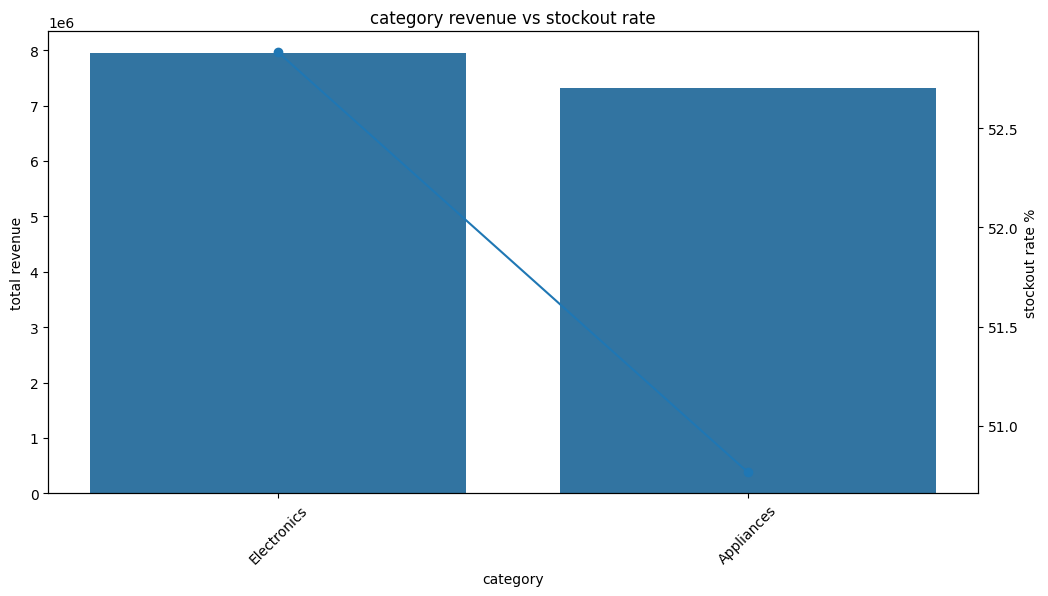

In [13]:
fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=category_summary,
    x="category",
    y="total_revenue",
    ax=ax1
)

ax1.set_title("category revenue vs stockout rate")
ax1.set_xlabel("category")
ax1.set_ylabel("total revenue")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(
    category_summary["category"],
    category_summary["stockout_rate"],
    marker="o"
)

ax2.set_ylabel("stockout rate %")
plt.show()

“Electronics may generate high revenue, but if its stockout rate is also high, Walmart is losing potential sales due to poor inventory planning.”

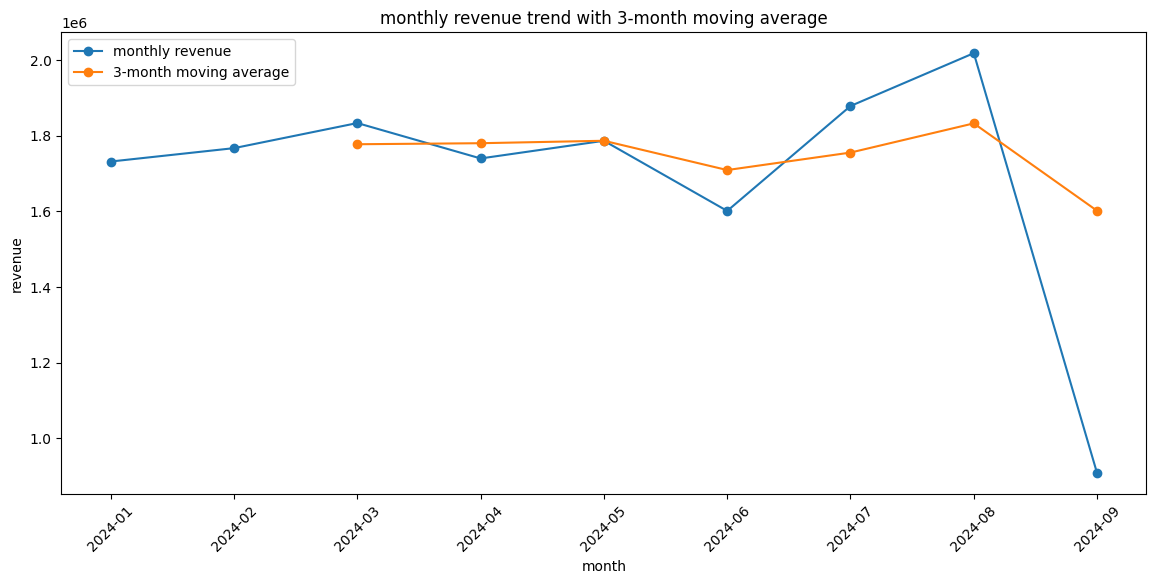

In [14]:
monthly_revenue = (
    df.groupby("year_month")
    .agg(total_revenue=("revenue", "sum"))
    .reset_index()
)

monthly_revenue["moving_avg_3_month"] = (
    monthly_revenue["total_revenue"]
    .rolling(window=3)
    .mean()
)

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_revenue["year_month"],
    monthly_revenue["total_revenue"],
    marker="o",
    label="monthly revenue"
)

plt.plot(
    monthly_revenue["year_month"],
    monthly_revenue["moving_avg_3_month"],
    marker="o",
    label="3-month moving average"
)

plt.title("monthly revenue trend with 3-month moving average")
plt.xlabel("month")
plt.ylabel("revenue")
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [15]:
store_scorecard = (
    df.groupby("store_location")
    .agg(
        total_revenue=("revenue", "sum"),
        total_transactions=("transaction_id", "nunique"),
        avg_transaction_value=("revenue", "mean"),
        stockout_rate=("stockout_indicator", lambda x: x.mean() * 100),
        avg_forecast_error=("forecast_error_percentage", "mean"),
        promotion_usage=("promotion_applied", lambda x: x.mean() * 100)
    )
    .reset_index()
)

store_scorecard = store_scorecard.sort_values(
    "total_revenue",
    ascending=False
)

store_scorecard

,store_location,total_revenue,total_transactions,avg_transaction_value,stockout_rate,avg_forecast_error,promotion_usage
2,"Los Angeles, CA","3,276,299.63",1038,"3,156.36",52.22,56.67,51.16
0,"Chicago, IL","3,156,726.82",1013,"3,116.22",51.23,60.25,53.41
4,"New York, NY","2,964,077.24",987,"3,003.12",55.42,61.06,51.98
3,"Miami, FL","2,962,567.02",964,"3,073.20",50.73,61.55,53.01
1,"Dallas, TX","2,903,930.74",998,"2,909.75",49.70,60.29,51.20


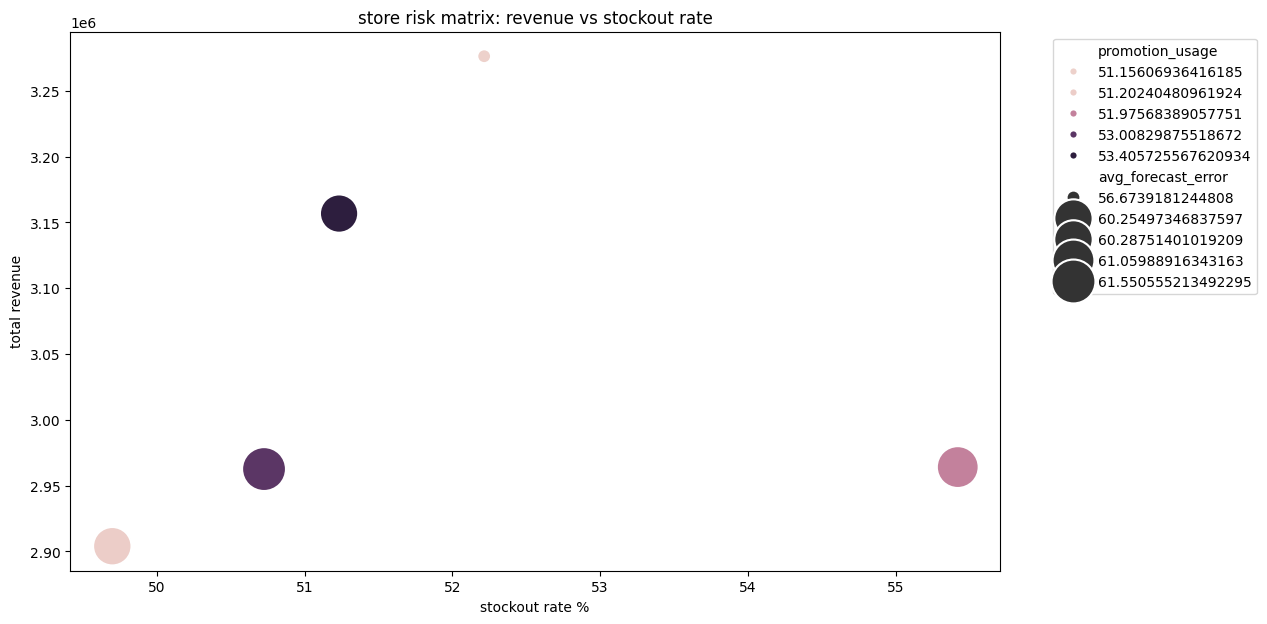

In [16]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=store_scorecard,
    x="stockout_rate",
    y="total_revenue",
    size="avg_forecast_error",
    hue="promotion_usage",
    sizes=(100, 1000)
)

plt.title("store risk matrix: revenue vs stockout rate")
plt.xlabel("stockout rate %")
plt.ylabel("total revenue")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

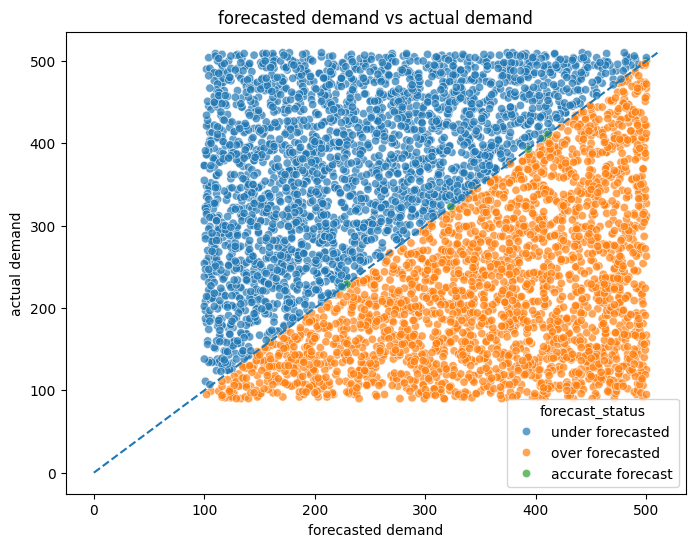

In [17]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="forecasted_demand",
    y="actual_demand",
    hue="forecast_status",
    alpha=0.7
)

max_value = max(df["forecasted_demand"].max(), df["actual_demand"].max())

plt.plot([0, max_value], [0, max_value], linestyle="--")

plt.title("forecasted demand vs actual demand")
plt.xlabel("forecasted demand")
plt.ylabel("actual demand")
plt.show()

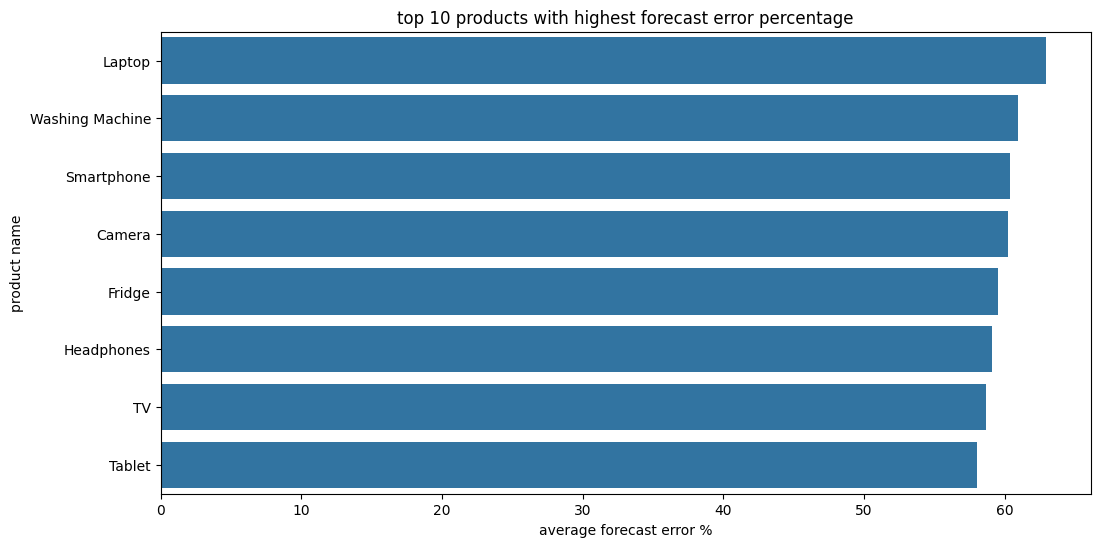

In [18]:
top_forecast_error_products = (
    df.groupby("product_name")
    .agg(
        avg_forecast_error_percentage=("forecast_error_percentage", "mean"),
        total_actual_demand=("actual_demand", "sum"),
        total_forecasted_demand=("forecasted_demand", "sum")
    )
    .sort_values("avg_forecast_error_percentage", ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_forecast_error_products,
    x="avg_forecast_error_percentage",
    y="product_name"
)

plt.title("top 10 products with highest forecast error percentage")
plt.xlabel("average forecast error %")
plt.ylabel("product name")
plt.show()

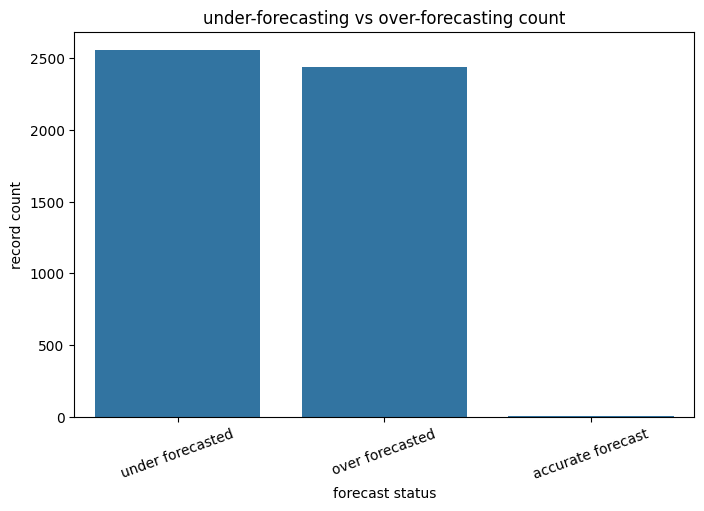

In [19]:
forecast_status_count = (
    df["forecast_status"]
    .value_counts()
    .reset_index()
)

forecast_status_count.columns = ["forecast_status", "record_count"]

plt.figure(figsize=(8, 5))

sns.barplot(
    data=forecast_status_count,
    x="forecast_status",
    y="record_count"
)

plt.title("under-forecasting vs over-forecasting count")
plt.xlabel("forecast status")
plt.ylabel("record count")
plt.xticks(rotation=20)
plt.show()

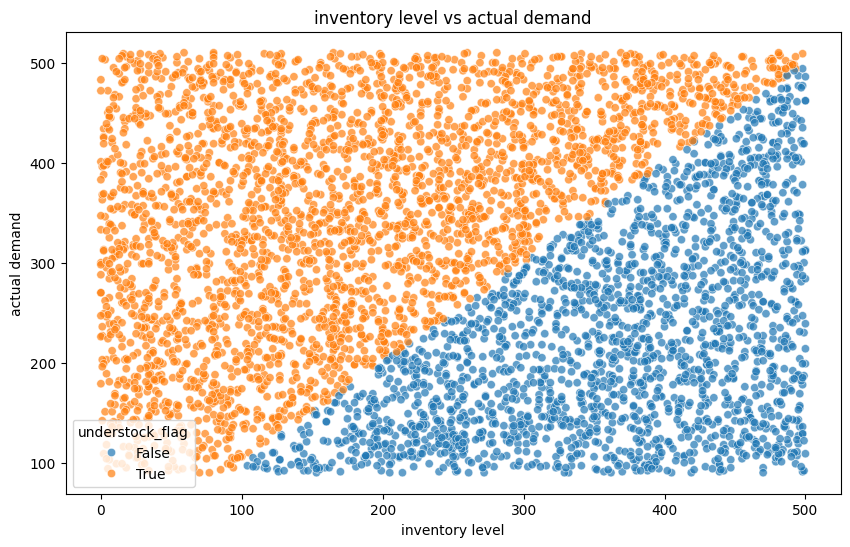

In [20]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="inventory_level",
    y="actual_demand",
    hue="understock_flag",
    alpha=0.7
)

plt.title("inventory level vs actual demand")
plt.xlabel("inventory level")
plt.ylabel("actual demand")
plt.show()

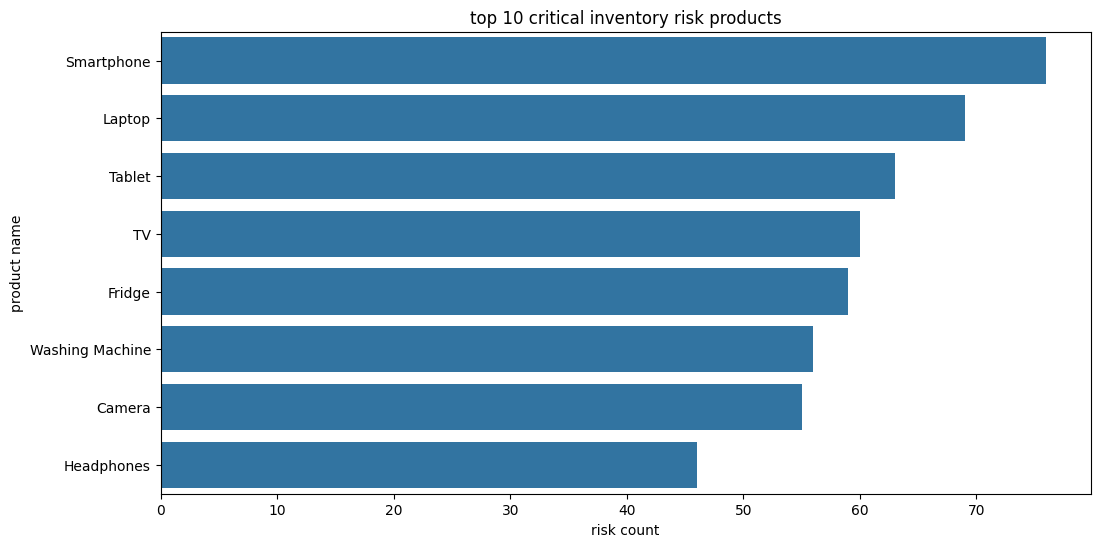

In [21]:
critical_products = (
    df[df["critical_inventory_risk"] == True]
    .groupby("product_name")
    .agg(
        risk_count=("transaction_id", "count"),
        total_actual_demand=("actual_demand", "sum"),
        avg_inventory_level=("inventory_level", "mean"),
        avg_reorder_point=("reorder_point", "mean")
    )
    .sort_values("risk_count", ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=critical_products,
    x="risk_count",
    y="product_name"
)

plt.title("top 10 critical inventory risk products")
plt.xlabel("risk count")
plt.ylabel("product name")
plt.show()

In [22]:
promotion_impact = (
    df.groupby("promotion_applied")
    .agg(
        total_revenue=("revenue", "sum"),
        avg_quantity_sold=("quantity_sold", "mean"),
        avg_actual_demand=("actual_demand", "mean"),
        stockout_rate=("stockout_indicator", lambda x: x.mean() * 100),
        avg_forecast_error=("forecast_error_percentage", "mean")
    )
    .reset_index()
)

promotion_impact

,promotion_applied,total_revenue,avg_quantity_sold,avg_actual_demand,stockout_rate,avg_forecast_error
0,False,"7,201,190.42",2.98,300.33,51.15,60.40
1,True,"8,062,411.03",2.98,297.95,52.51,59.50


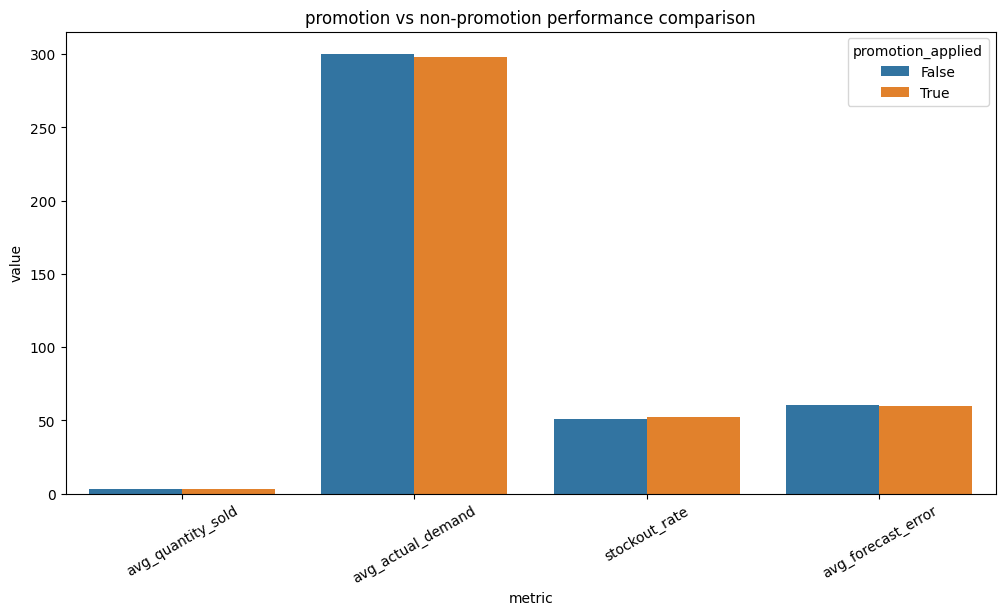

In [23]:
promotion_impact_melted = promotion_impact.melt(
    id_vars="promotion_applied",
    value_vars=[
        "avg_quantity_sold",
        "avg_actual_demand",
        "stockout_rate",
        "avg_forecast_error"
    ],
    var_name="metric",
    value_name="value"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=promotion_impact_melted,
    x="metric",
    y="value",
    hue="promotion_applied"
)

plt.title("promotion vs non-promotion performance comparison")
plt.xlabel("metric")
plt.ylabel("value")
plt.xticks(rotation=30)
plt.show()


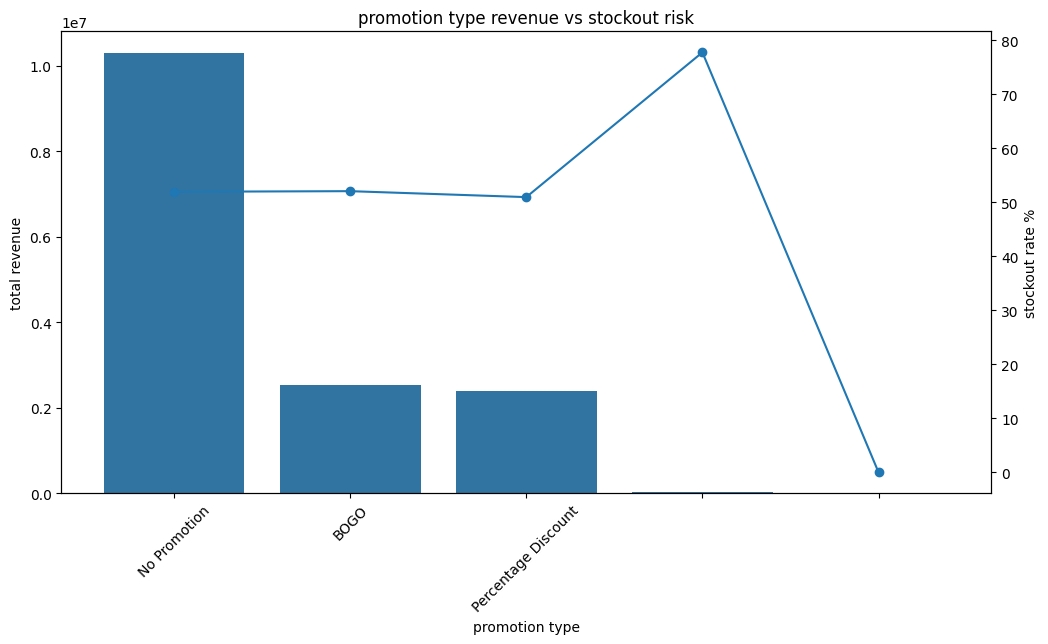

In [24]:
promotion_type_summary = (
    df.groupby("promotion_type")
    .agg(
        total_revenue=("revenue", "sum"),
        stockout_rate=("stockout_indicator", lambda x: x.mean() * 100),
        avg_quantity_sold=("quantity_sold", "mean"),
        avg_actual_demand=("actual_demand", "mean")
    )
    .sort_values("total_revenue", ascending=False)
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=promotion_type_summary,
    x="promotion_type",
    y="total_revenue",
    ax=ax1
)

ax1.set_title("promotion type revenue vs stockout risk")
ax1.set_xlabel("promotion type")
ax1.set_ylabel("total revenue")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(
    promotion_type_summary["promotion_type"],
    promotion_type_summary["stockout_rate"],
    marker="o"
)

ax2.set_ylabel("stockout rate %")

plt.show()

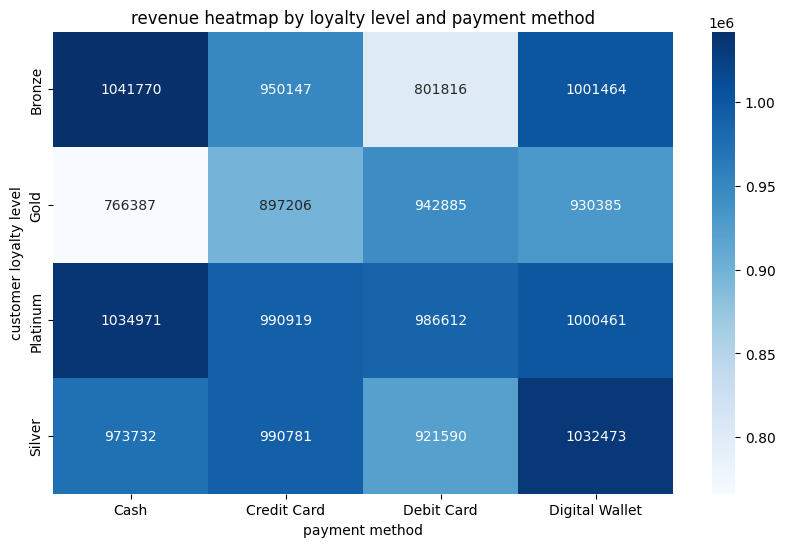

In [25]:
loyalty_payment = (
    df.pivot_table(
        index="customer_loyalty_level",
        columns="payment_method",
        values="revenue",
        aggfunc="sum"
    )
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    loyalty_payment,
    annot=True,
    fmt=".0f",
    cmap="Blues"
)

plt.title("revenue heatmap by loyalty level and payment method")
plt.xlabel("payment method")
plt.ylabel("customer loyalty level")
plt.show()

In [26]:
df["age_group"] = pd.cut(
    df["customer_age"],
    bins=[17, 25, 40, 60, 100],
    labels=["18-25", "26-40", "41-60", "60+"]
)

df["income_group"] = pd.cut(
    df["customer_income"],
    bins=[0, 40000, 70000, 100000, np.inf],
    labels=["low income", "middle income", "high income", "premium income"]
)

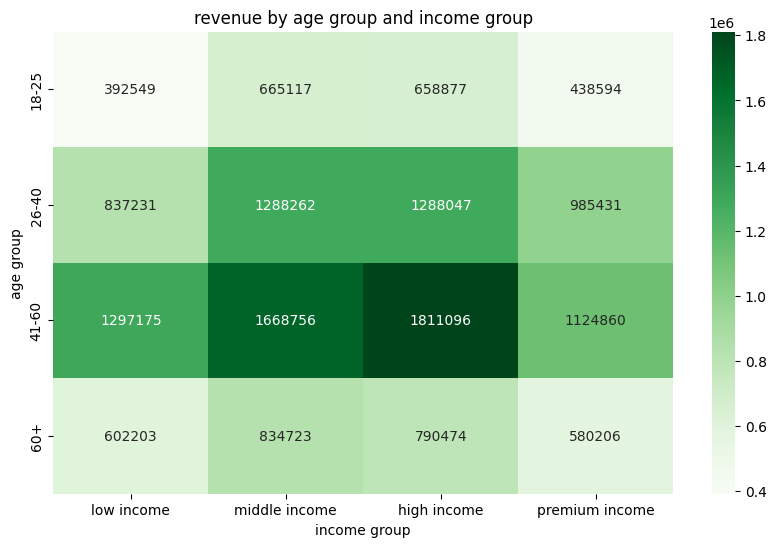

In [27]:
customer_segment_revenue = (
    df.groupby(["age_group", "income_group"], observed=False)
    .agg(total_revenue=("revenue", "sum"))
    .reset_index()
)

segment_pivot = customer_segment_revenue.pivot(
    index="age_group",
    columns="income_group",
    values="total_revenue"
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    segment_pivot,
    annot=True,
    fmt=".0f",
    cmap="Greens"
)

plt.title("revenue by age group and income group")
plt.xlabel("income group")
plt.ylabel("age group")
plt.show()

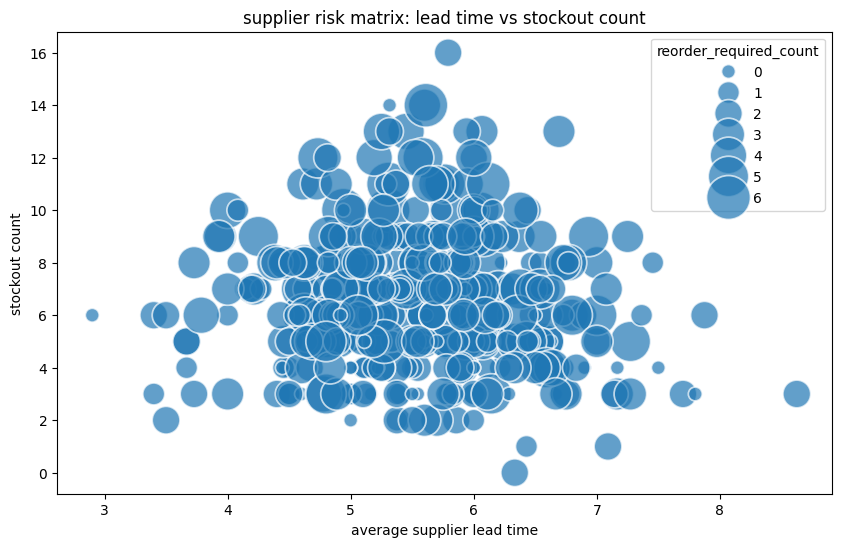

In [28]:
supplier_risk = (
    df.groupby("supplier_id")
    .agg(
        avg_supplier_lead_time=("supplier_lead_time", "mean"),
        stockout_count=("stockout_indicator", "sum"),
        reorder_required_count=("reorder_required", "sum"),
        avg_inventory_gap=("inventory_gap", "mean")
    )
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=supplier_risk,
    x="avg_supplier_lead_time",
    y="stockout_count",
    size="reorder_required_count",
    sizes=(100, 1000),
    alpha=0.7
)

plt.title("supplier risk matrix: lead time vs stockout count")
plt.xlabel("average supplier lead time")
plt.ylabel("stockout count")
plt.show()

In [29]:
holiday_summary = (
    df.groupby("holiday_indicator")
    .agg(
        total_revenue=("revenue", "sum"),
        avg_actual_demand=("actual_demand", "mean"),
        stockout_rate=("stockout_indicator", lambda x: x.mean() * 100),
        avg_forecast_error=("forecast_error_percentage", "mean")
    )
    .reset_index()
)

holiday_summary

,holiday_indicator,total_revenue,avg_actual_demand,stockout_rate,avg_forecast_error
0,False,"7,595,258.88",298.46,51.58,59.11
1,True,"7,668,342.57",299.72,52.14,60.74


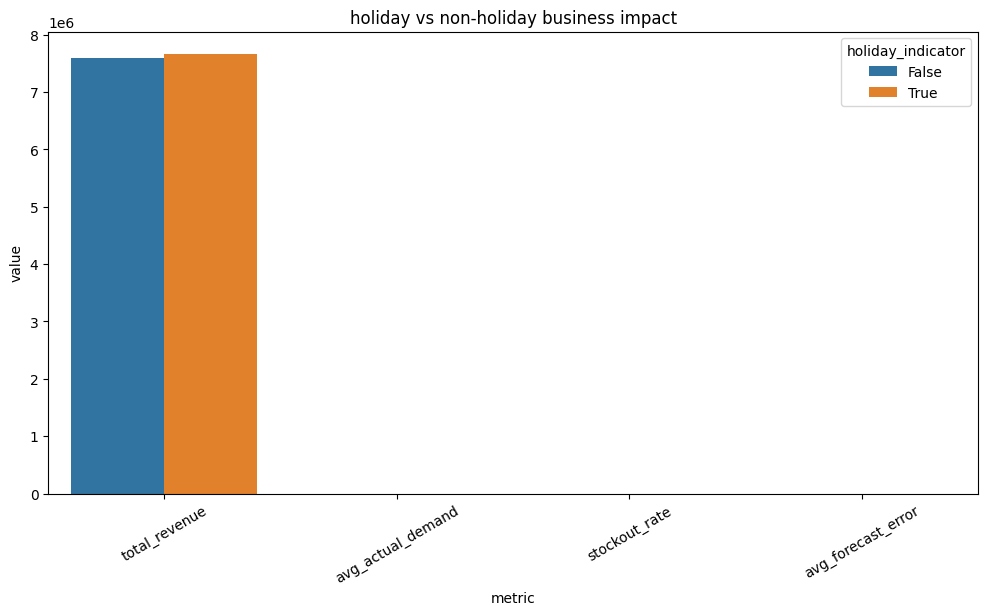

In [30]:
holiday_melted = holiday_summary.melt(
    id_vars="holiday_indicator",
    value_vars=[
        "total_revenue",
        "avg_actual_demand",
        "stockout_rate",
        "avg_forecast_error"
    ],
    var_name="metric",
    value_name="value"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=holiday_melted,
    x="metric",
    y="value",
    hue="holiday_indicator"
)

plt.title("holiday vs non-holiday business impact")
plt.xlabel("metric")
plt.ylabel("value")
plt.xticks(rotation=30)
plt.show()

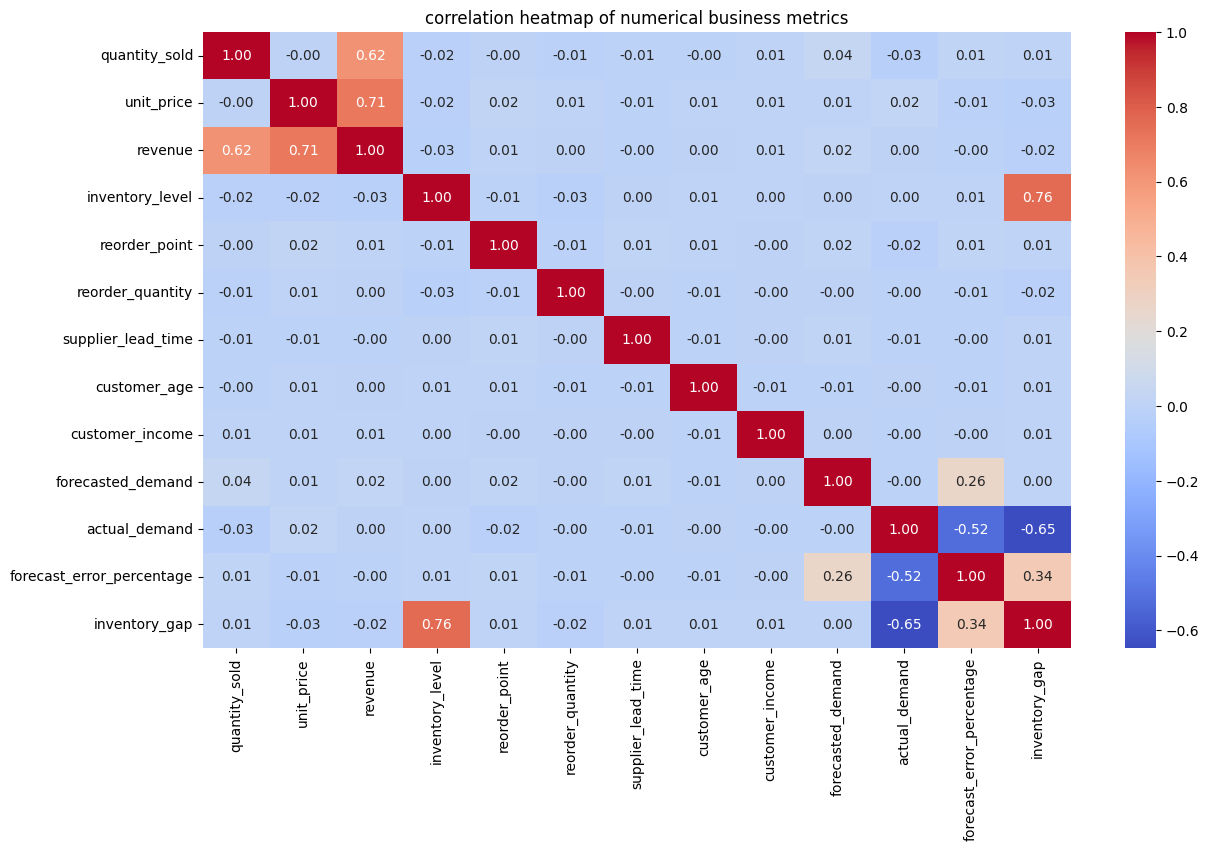

In [31]:
corr_cols = [
    "quantity_sold",
    "unit_price",
    "revenue",
    "inventory_level",
    "reorder_point",
    "reorder_quantity",
    "supplier_lead_time",
    "customer_age",
    "customer_income",
    "forecasted_demand",
    "actual_demand",
    "forecast_error_percentage",
    "inventory_gap"
]

correlation_matrix = df[corr_cols].corr()

plt.figure(figsize=(14, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("correlation heatmap of numerical business metrics")
plt.show()

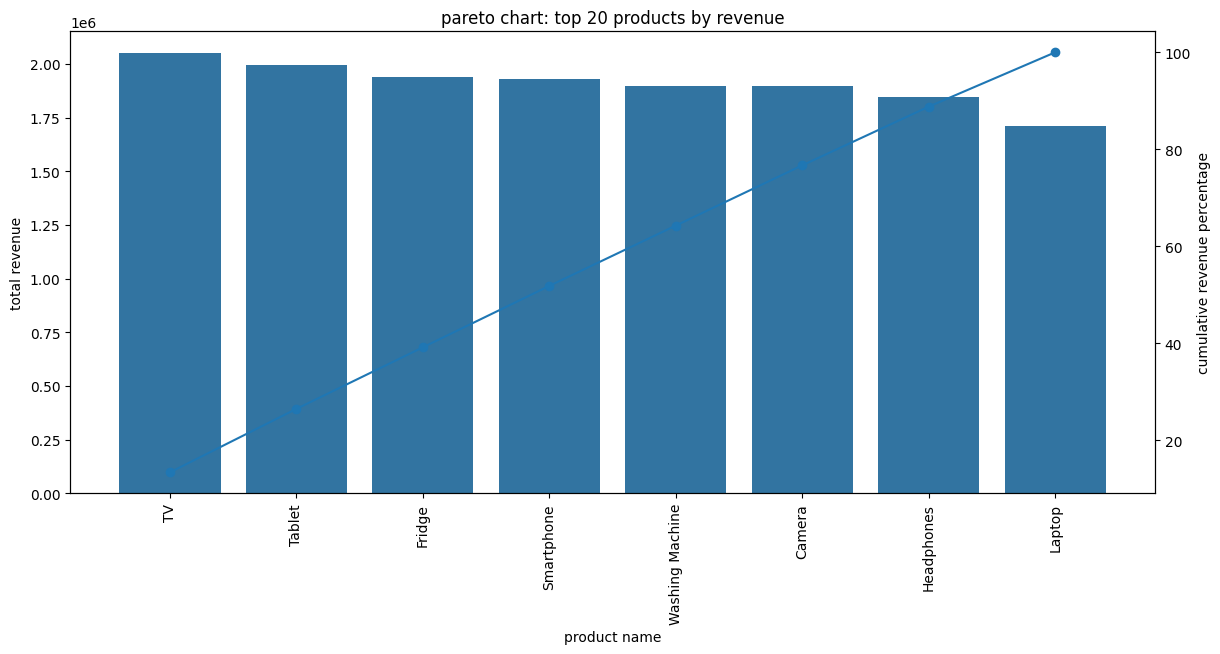

In [32]:
product_revenue = (
    df.groupby("product_name")
    .agg(total_revenue=("revenue", "sum"))
    .sort_values("total_revenue", ascending=False)
    .reset_index()
)

product_revenue["revenue_percentage"] = (
    product_revenue["total_revenue"] / product_revenue["total_revenue"].sum()
) * 100

product_revenue["cumulative_percentage"] = (
    product_revenue["revenue_percentage"].cumsum()
)

top_20_products = product_revenue.head(20)

fig, ax1 = plt.subplots(figsize=(14, 6))

sns.barplot(
    data=top_20_products,
    x="product_name",
    y="total_revenue",
    ax=ax1
)

ax1.set_ylabel("total revenue")
ax1.set_xlabel("product name")
ax1.tick_params(axis="x", rotation=90)

ax2 = ax1.twinx()
ax2.plot(
    top_20_products["product_name"],
    top_20_products["cumulative_percentage"],
    marker="o"
)

ax2.set_ylabel("cumulative revenue percentage")

plt.title("pareto chart: top 20 products by revenue")
plt.show()

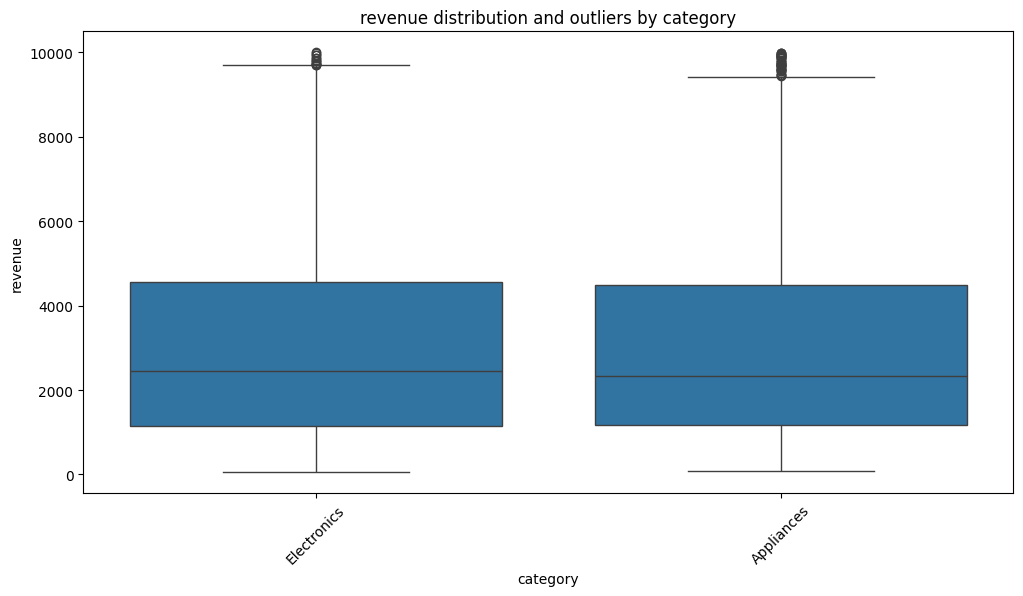

In [33]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="category",
    y="revenue"
)

plt.title("revenue distribution and outliers by category")
plt.xlabel("category")
plt.ylabel("revenue")
plt.xticks(rotation=45)
plt.show()

In [34]:
store_scorecard["store_attention"] = np.where(
    (store_scorecard["total_revenue"] < store_scorecard["total_revenue"].median()) &
    (store_scorecard["stockout_rate"] > store_scorecard["stockout_rate"].median()),
    "urgent attention",
    np.where(
        (store_scorecard["total_revenue"] > store_scorecard["total_revenue"].median()) &
        (store_scorecard["stockout_rate"] > store_scorecard["stockout_rate"].median()),
        "high revenue but inventory risk",
        "normal"
    )
)

store_scorecard.sort_values(
    ["store_attention", "stockout_rate"],
    ascending=[True, False]
)

,store_location,total_revenue,total_transactions,avg_transaction_value,stockout_rate,avg_forecast_error,promotion_usage,store_attention
2,"Los Angeles, CA","3,276,299.63",1038,"3,156.36",52.22,56.67,51.16,high revenue but inventory risk
4,"New York, NY","2,964,077.24",987,"3,003.12",55.42,61.06,51.98,normal
0,"Chicago, IL","3,156,726.82",1013,"3,116.22",51.23,60.25,53.41,normal
3,"Miami, FL","2,962,567.02",964,"3,073.20",50.73,61.55,53.01,normal
1,"Dallas, TX","2,903,930.74",998,"2,909.75",49.70,60.29,51.20,normal


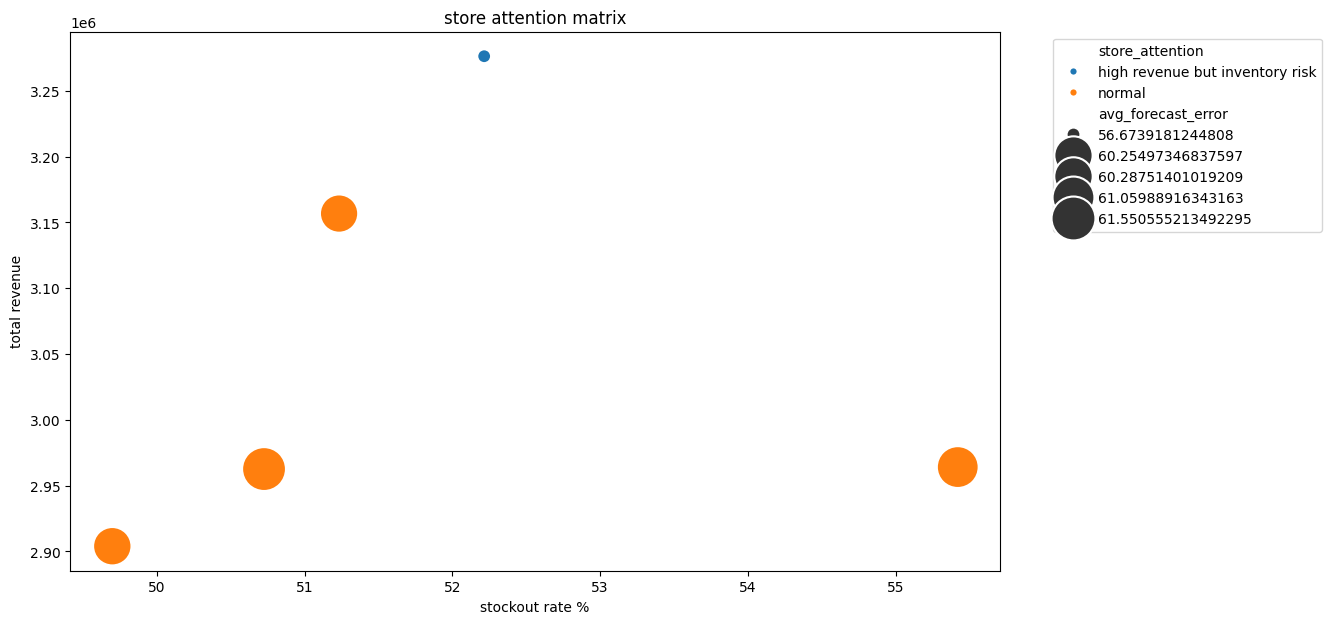

In [35]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=store_scorecard,
    x="stockout_rate",
    y="total_revenue",
    hue="store_attention",
    size="avg_forecast_error",
    sizes=(100, 1000)
)

plt.title("store attention matrix")
plt.xlabel("stockout rate %")
plt.ylabel("total revenue")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [36]:
# optional: save the cleaned dataframe after all feature engineering
# use this only after df contains all final engineered columns

# df.to_csv("walmart_sales_cleaned_final.csv", index=False)
# print("saved walmart_sales_cleaned_final.csv successfully")


# Business Insights & Management Recommendations

## Executive KPI Snapshot

| KPI | Result | Business meaning |
|---|---:|---|
| Total revenue | **15,263,601.45** | Strong overall sales base for analysis |
| Total transactions | **5,000** | Enough records for directional business insights |
| Total quantity sold | **14,914** | Average basket quantity is around 3 units |
| Average transaction value | **3,052.72** | Useful benchmark for store and promotion comparison |
| Stockout rate | **51.86%** | Very high inventory risk; this is the biggest business problem |
| Understock rate | **59.80%** | Inventory planning is not matching actual demand |
| Average forecast error % | **59.93%** | Forecasting quality is weak and directly affects stockouts/reorder decisions |
| Promotion usage | **52.14%** | Promotions are widely used, but they must be controlled because they increase stockout pressure |

## What the project is really showing

This is not only a sales dashboard. The real business story is:

**Walmart is generating strong revenue, but inventory and forecasting problems are creating missed-sales risk. Promotions improve revenue slightly, but they also increase stockout risk. The best business solution is not “more promotions”; it is better demand forecasting, store-level replenishment, and supplier control.**

## Insight 1 — Electronics is the main revenue engine, but stockout risk is also higher

- Electronics generated **7,941,631.80** revenue.
- Appliances generated **7,321,969.65** revenue.
- Electronics contributes around **52%** of total revenue.
- Electronics also has a higher stockout rate: **52.88%** vs **50.77%** for Appliances.

**Business decision:** Prioritize Electronics inventory planning first because it is the highest revenue category and has higher stockout pressure.

## Insight 2 — Los Angeles is the highest revenue location, but New York has the highest stockout risk

Store-location revenue ranking:

| Store location | Revenue | Stockout rate |
|---|---:|---:|
| Los Angeles, CA | **3,276,299.63** | 52.22% |
| Chicago, IL | 3,156,726.82 | 51.23% |
| New York, NY | 2,964,077.24 | **55.42%** |
| Miami, FL | 2,962,567.02 | 50.73% |
| Dallas, TX | 2,903,930.74 | 49.70% |

**Business decision:**
- Protect Los Angeles because it is the largest revenue driver.
- Fix New York because it has the highest stockout rate.
- Miami needs operational attention because it has low revenue and high forecast error in the scorecard.

## Insight 3 — Inventory is the biggest operational weakness

- Overall stockout rate is **51.86%**.
- Understock rate is **59.80%**.
- Around **2,990 records** have actual demand greater than inventory.
- Around **945 records** are below reorder point.

Top urgent high-demand, low-inventory products:

| Product id | Product | Category | Store | Demand gap |
|---:|---|---|---|---:|
| 801 | TV | Appliances | Dallas, TX | **734.0** |
| 439 | Camera | Appliances | New York, NY | **715.5** |
| 210 | Smartphone | Electronics | Dallas, TX | **692.5** |
| 952 | Fridge | Appliances | Los Angeles, CA | **679.5** |
| 652 | Laptop | Electronics | New York, NY | **596.0** |

**Business decision:** Create an urgent reorder list using demand gap, stockout flag, reorder point, and supplier lead time. Do not reorder only by low inventory; reorder by **business risk**.

## Insight 4 — Forecasting is weak and must be improved before scaling promotions

- Average forecast error percentage is **59.93%**.
- Under-forecasted records: **2,555** records (**51.10%**).
- Over-forecasted records: **2,436** records (**48.72%**).
- Accurate forecast records: only **9** records (**0.18%**).

Top forecast error products:

| Product id | Product | Category | Avg forecast error % |
|---:|---|---|---:|
| 142 | Laptop | Electronics | **446.15%** |
| 109 | Fridge | Electronics | **426.32%** |
| 813 | Washing Machine | Electronics | **423.33%** |
| 394 | Tablet | Appliances | **416.84%** |
| 842 | Camera | Electronics | **410.31%** |

**Business decision:** Forecasting failure is not limited to one product type. Build product-store-level forecast monitoring and flag any product with error above 25–30%.

## Insight 5 — Promotions increase revenue but also increase inventory pressure

| Promotion status | Revenue | Transactions | Avg transaction value | Stockout rate |
|---|---:|---:|---:|---:|
| Promotion applied | **8,062,411.03** | 2,607 | 3,092.60 | **52.51%** |
| No promotion | 7,201,190.42 | 2,393 | 3,009.27 | 51.15% |

Promotions generate higher revenue and higher average transaction value, but stockout rate increases by **1.36 percentage points**.

**Business decision:** Promotions should not be applied blindly. Use promotions only when inventory cover is enough and supplier lead time is under control.

## Insight 6 — BOGO is the best real promotion type, but promotion_type needs cleaning

Promotion type results show:
- `No Promotion` generates high revenue because it is the default non-promotion bucket.
- Among real promotions, **BOGO** performs better than Percentage Discount.
- There are dirty/blank promotion_type values that must be cleaned before final reporting.

**Business decision:** Report promotion performance in two layers:
1. Promotion vs no promotion
2. BOGO vs Percentage Discount only for promoted transactions

## Insight 7 — Customer targeting should focus on Platinum customers

- Platinum loyalty customers generate the highest revenue: **4,012,963.14**.
- Credit Card is the most used payment method with **1,281 transactions** and **25.62% usage**.
- Digital Wallet contributes the highest payment-method revenue: **3,964,782.71**.

**Business decision:** Target Platinum customers with controlled promotions on high-margin products, but avoid promoting products that are already understocked.

## Insight 8 — Holiday demand is only slightly higher, but forecast error also increases

| Day type | Revenue | Avg actual demand | Stockout rate | Avg forecast error % |
|---|---:|---:|---:|---:|
| Holiday | **7,668,342.57** | **299.72** | **52.14%** | **60.74%** |
| Non-holiday | 7,595,258.88 | 298.46 | 51.58% | 59.11% |

Holiday performance is slightly higher, but the difference is not huge. Do not exaggerate this insight.

**Business decision:** Use holiday planning, but do not claim holidays are the only reason for stockout problems.

## Insight 9 — Supplier risk should be connected to stockout risk

High-risk suppliers include:
- Supplier **470**: 16 stockout cases, 66.67% stockout rate.
- Supplier **442**: 14 stockout cases, 77.78% stockout rate.
- Supplier **333**: 13 stockout cases, 100% stockout rate.
- Supplier **321** has very high lead time in the recommendation query.

**Business decision:** Create supplier scorecards based on lead time, stockout count, affected products, and affected stores.

## Final Top 7 Business Recommendations

1. **Fix inventory first, not dashboards first.** Stockout rate is **51.86%**, which is too high for a retail operation.
2. **Prioritize Electronics replenishment.** It is the highest revenue category and has higher stockout pressure.
3. **Build a New York stockout reduction plan.** New York has the highest location stockout rate at **55.42%**.
4. **Protect Los Angeles revenue.** It is the highest revenue location but still has **52.22%** stockout risk.
5. **Audit forecast logic.** Average forecast error is **59.93%**, and accurate forecasts are only **0.18%** of records.
6. **Run promotions only with inventory checks.** Promotions increase revenue, but stockout risk also increases.
7. **Create supplier escalation rules.** Suppliers with high lead time and high stockout count should be reviewed before reorder planning.